# XGBoost Model

### Load Data

In [1]:
import yfinance

symbol = "BTC-USD"

start = "2014-01-01"

end = "2021-01-01"

dataframe = yfinance.download(symbol, start, end)

dataframe

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893


In [2]:
dataframe.to_csv("btc-usd-2014-2021.csv")

In [3]:
dataframe

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2020-12-27,26272.294922,28288.839844,25922.769531,26439.373047,66479895605
2020-12-28,27084.808594,27389.111328,26207.640625,26280.822266,49056742893


In [4]:
#Define X and y
y = dataframe["Close"].values

y

array([[  457.33401489],
       [  424.44000244],
       [  394.79598999],
       ...,
       [27362.4375    ],
       [28840.953125  ],
       [29001.72070312]])

In [6]:
X = dataframe[["Open", "High", "Low", "Volume"]].values

X

array([[4.65864014e+02, 4.68174011e+02, 4.52421997e+02, 2.10568000e+07],
       [4.56859985e+02, 4.56859985e+02, 4.13104004e+02, 3.44832000e+07],
       [4.24102997e+02, 4.27834991e+02, 3.84532013e+02, 3.79197000e+07],
       ...,
       [2.70818105e+04, 2.73707207e+04, 2.59872988e+04, 4.52659468e+10],
       [2.73600898e+04, 2.89377402e+04, 2.73600898e+04, 5.12874427e+10],
       [2.88415742e+04, 2.92448770e+04, 2.82019922e+04, 4.67549648e+10]])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train.shape

(1723, 4)

In [8]:
X_test.shape

(575, 4)

In [9]:
y_train.shape

(1723, 1)

In [10]:
y_test.shape

(575, 1)

In [12]:
#!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 26.9 MB/s eta 0:00:04
   ----- ---------------------------------- 13.6/101.7 MB 45.0 MB/s eta 0:00:02
   --------- ------------------------------ 24.6/101.7 MB 48.8 MB/s eta 0:00:02
   -------------- ------------------------- 37.2/101.7 MB 51.4 MB/s eta 0:00:02
   ------------------- -------------------- 48.5/101.7 MB 52.3 MB/s eta 0:00:02
   ----------------------- ---------------- 59.8/101.7 MB 52.2 MB/s eta 0:00:01
   ---------------------------- ----------- 71.3/101.7 MB 52.3 MB/s eta 0:00:01
   -------------------------------- ------- 82.3/101.7 MB 52.5 MB/s eta 0:00:01
   ------------------------------------ --- 92.0/101.7 MB 52.9 MB/s eta 0:00:01
   --------------------------------------  100.7/101.7 MB 50.6 MB/s eta 0:00:01
   --------------------------------------- 101.7/101.7 MB 47.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
#Build XGBoost Regressor
#Predict price of crypto

import xgboost

from xgboost import XGBRegressor

model = XGBRegressor(objective = "reg:squarederror")

model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [14]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

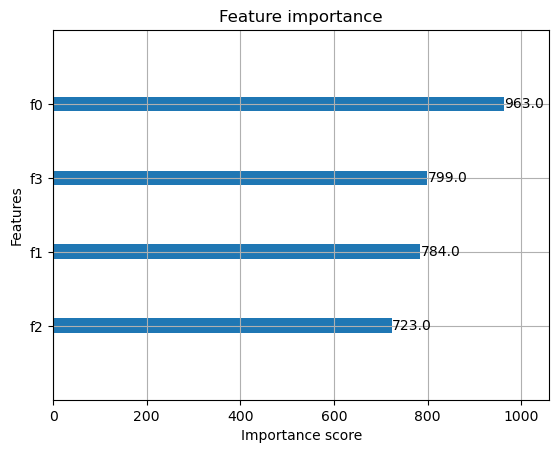

In [15]:
xgboost.plot_importance(model)

In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer()

X_train = imputer.fit_transform(X_train)

X_train

array([[1.54087000e+03, 1.61803003e+03, 1.53031006e+03, 9.46035968e+08],
       [2.34824997e+02, 2.39520996e+02, 2.29022003e+02, 2.81537000e+07],
       [3.68697314e+03, 3.69897827e+03, 3.65381079e+03, 4.77817088e+09],
       ...,
       [3.81733002e+02, 3.88104004e+02, 3.76665009e+02, 5.44039000e+07],
       [6.22927002e+02, 6.25094971e+02, 6.22395020e+02, 4.50168000e+07],
       [3.59330994e+02, 3.70274994e+02, 3.57411987e+02, 5.07149000e+07]])

In [17]:
X_test = imputer.fit_transform(X_test)

X_test

array([[2.44751007e+02, 2.46117996e+02, 2.39399994e+02, 2.16435000e+07],
       [3.69561304e+03, 3.69561304e+03, 3.64228784e+03, 6.27705643e+09],
       [2.36535004e+02, 2.37727997e+02, 2.33494995e+02, 1.23879000e+07],
       ...,
       [9.12160059e+03, 9.16322070e+03, 8.89074414e+03, 3.62169304e+10],
       [1.03138564e+04, 1.03415557e+04, 9.87442773e+03, 4.38650548e+10],
       [1.82639297e+04, 1.82684531e+04, 1.76195332e+04, 2.79196410e+10]])

In [23]:
imputed_model = XGBRegressor(objective = "reg:squarederror")

imputed_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [24]:
predicted_y = imputed_model.predict(X_test)

In [25]:
#Model accuracy

from sklearn.metrics import mean_absolute_error

mean_absolute_error(predicted_y, y_test)

78.19306186841882

In [26]:
imputed_model.score(X_test, y_test)

0.998466211980305